## Loading data and preprocessing

In [1]:
# Import Required Libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST Data
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train.reshape(-1, 28*28).astype('float32') / 255.0
x_test = x_test.reshape(-1, 28*28).astype('float32') / 255.0

# One-hot encode labels
y_train_ohe = tf.keras.utils.to_categorical(y_train, 10)
y_test_ohe = tf.keras.utils.to_categorical(y_test, 10)

# Build the same model architecture
def create_model():
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(784,)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Manual Training with tf.GradientTape()

In [2]:
# Create the model and optimizer
model_manual = create_model()
optimizer = tf.keras.optimizers.Adam()
loss_fn = tf.keras.losses.CategoricalCrossentropy()

# For tracking metrics
train_losses, train_accuracies = [], []

# Training Parameters
epochs = 5
batch_size = 64

# Training loop
for epoch in range(epochs):
    print(f"Epoch {epoch+1}/{epochs}")
    indices = np.arange(len(x_train))
    np.random.shuffle(indices)
    x_train_shuffled = x_train[indices]
    y_train_shuffled = y_train_ohe[indices]

    batch_losses = []
    correct = 0

    for i in range(0, len(x_train), batch_size):
        x_batch = x_train_shuffled[i:i+batch_size]
        y_batch = y_train_shuffled[i:i+batch_size]

        with tf.GradientTape() as tape:
            logits = model_manual(x_batch, training=True)
            loss = loss_fn(y_batch, logits)

        grads = tape.gradient(loss, model_manual.trainable_variables)
        optimizer.apply_gradients(zip(grads, model_manual.trainable_variables))

        batch_losses.append(loss.numpy())
        correct += np.sum(np.argmax(logits.numpy(), axis=1) == np.argmax(y_batch, axis=1))

    accuracy = correct / len(x_train)
    avg_loss = np.mean(batch_losses)
    train_losses.append(avg_loss)
    train_accuracies.append(accuracy)

    print(f"Loss: {avg_loss:.4f} - Accuracy: {accuracy:.4f}")


Epoch 1/5
Loss: 0.2899 - Accuracy: 0.9134
Epoch 2/5
Loss: 0.1150 - Accuracy: 0.9652
Epoch 3/5
Loss: 0.0797 - Accuracy: 0.9753
Epoch 4/5
Loss: 0.0651 - Accuracy: 0.9799
Epoch 5/5
Loss: 0.0506 - Accuracy: 0.9838


## Training with model.fit()

In [3]:
# Create a new identical model
model_fit = create_model()
model_fit.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

# Train using model.fit
history = model_fit.fit(
    x_train, y_train_ohe,
    batch_size=64,
    epochs=5,
    validation_data=(x_test, y_test_ohe)
)


Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8217 - loss: 0.5790 - val_accuracy: 0.9561 - val_loss: 0.1469
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9623 - loss: 0.1251 - val_accuracy: 0.9646 - val_loss: 0.1144
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9752 - loss: 0.0829 - val_accuracy: 0.9693 - val_loss: 0.0990
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9812 - loss: 0.0603 - val_accuracy: 0.9696 - val_loss: 0.1030
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9845 - loss: 0.0497 - val_accuracy: 0.9739 - val_loss: 0.0836


## Performance Comparison Plot

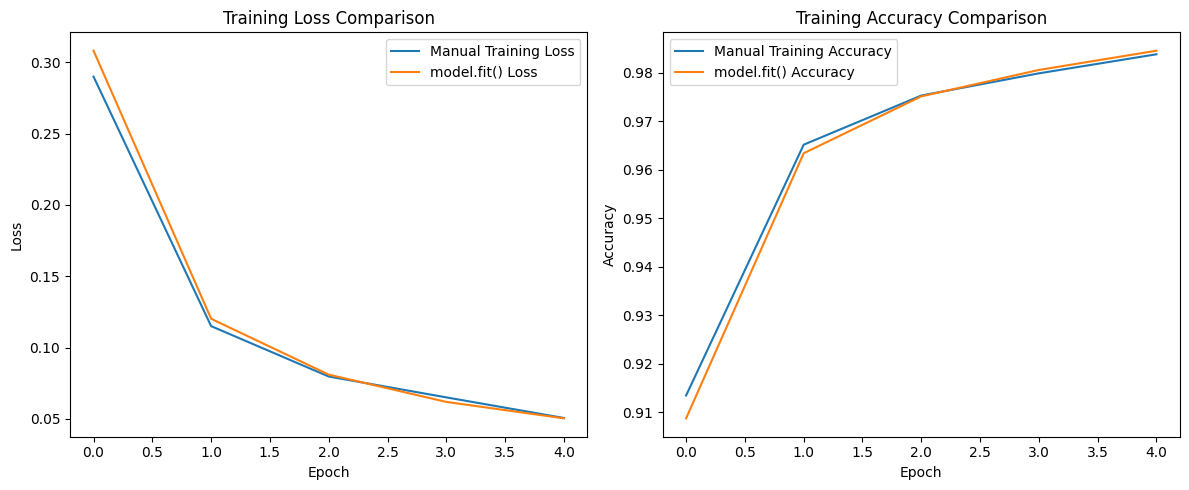

In [4]:
# Plot Loss
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label='Manual Training Loss')
plt.plot(history.history['loss'], label='model.fit() Loss')
plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Plot Accuracy
plt.subplot(1,2,2)
plt.plot(train_accuracies, label='Manual Training Accuracy')
plt.plot(history.history['accuracy'], label='model.fit() Accuracy')
plt.title("Training Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()
